# 4. Sensitivity analysis

This notebook reproduces the report's sensitivity figures and candidate-selection robustness.

The fixed E300/D80 design is replayed under all 36 combinations of four elasticity windows, three BAL allocations, and three access-scaling values. The complete target surface is then replayed under the central specification and seven single-parameter alternatives, allowing one global candidate to be selected across every propagation time and target pair.

In [1]:
from pathlib import Path
import os
import subprocess
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, display

def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "src").is_dir() and (candidate / "scripts").is_dir():
            return candidate
    raise RuntimeError("Could not locate the repository root")

PROJECT_ROOT = find_project_root(Path.cwd())
SRC_DIR = PROJECT_ROOT / "src"
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
for path in (SRC_DIR, SCRIPTS_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

DATA_DIR = PROJECT_ROOT / "data"
OUT_DIR = DATA_DIR / "7999"
PLOTS_DIR = PROJECT_ROOT / "plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

REFRESH_FROM_NETWORK = (
    os.environ.get("REFRESH_7999_SIMULATION_FROM_NETWORK", "0") == "1"
)
REUSE_OUTPUTS = os.environ.get("REUSE_7999_SIMULATION_OUTPUTS", "0") == "1"

def run_script(script: str, *args: str) -> None:
    command = [sys.executable, str(SCRIPTS_DIR / script), *map(str, args)]
    print("+", " ".join(command))
    subprocess.run(command, cwd=PROJECT_ROOT, check=True)

print("project root:", PROJECT_ROOT)
print("network refresh:", REFRESH_FROM_NETWORK)
print("reuse generated outputs:", REUSE_OUTPUTS)

project root: /Users/william/PycharmProjects/eip-7999-research
network refresh: False
reuse generated outputs: True


## Run the sensitivity simulations

This is the most expensive stage. By default it reruns both the 36-case fixed-design diagnostic and the eight complete target surfaces. Set REUSE_7999_SIMULATION_OUTPUTS=1 to regenerate tables and figures from an existing local sensitivity run.

In [2]:
import run_slot_time_parameter_sensitivity
import make_slot_time_parameter_sensitivity

fixed_path = OUT_DIR / "slot_time_e300_d80_parameter_sensitivity.csv"
surface_path = OUT_DIR / "slot_time_parameter_surface_one_at_a_time.csv"

if not REUSE_OUTPUTS:
    run_slot_time_parameter_sensitivity.main()
elif not fixed_path.exists() or not surface_path.exists():
    raise FileNotFoundError(
        "Sensitivity outputs are missing; rerun without "
        "REUSE_7999_SIMULATION_OUTPUTS=1"
    )

make_slot_time_parameter_sensitivity.main()

wrote sensitivity figures, 40 maximum-throughput rows, 31/40 balanced rows, 10 split-summary rows, and 8 global-candidate rows


## Fixed-design sensitivity figures

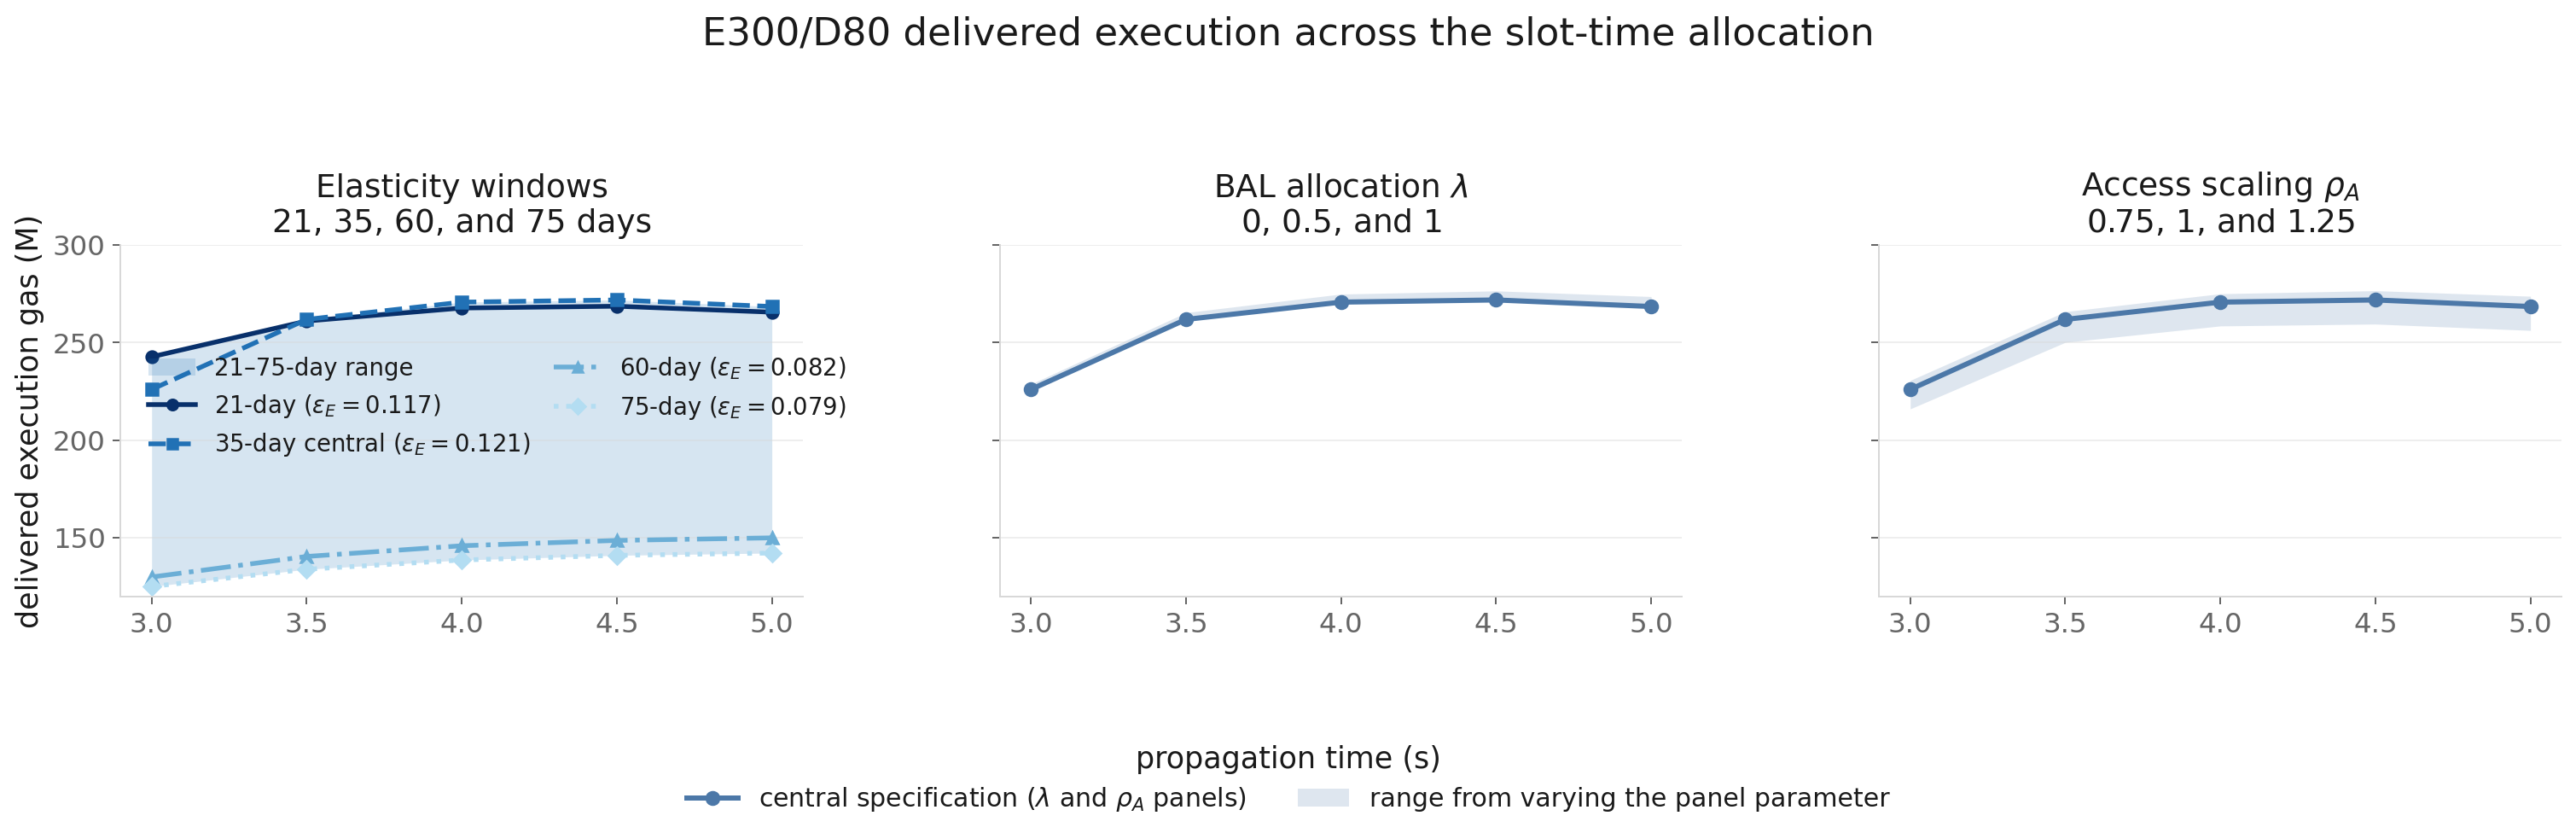

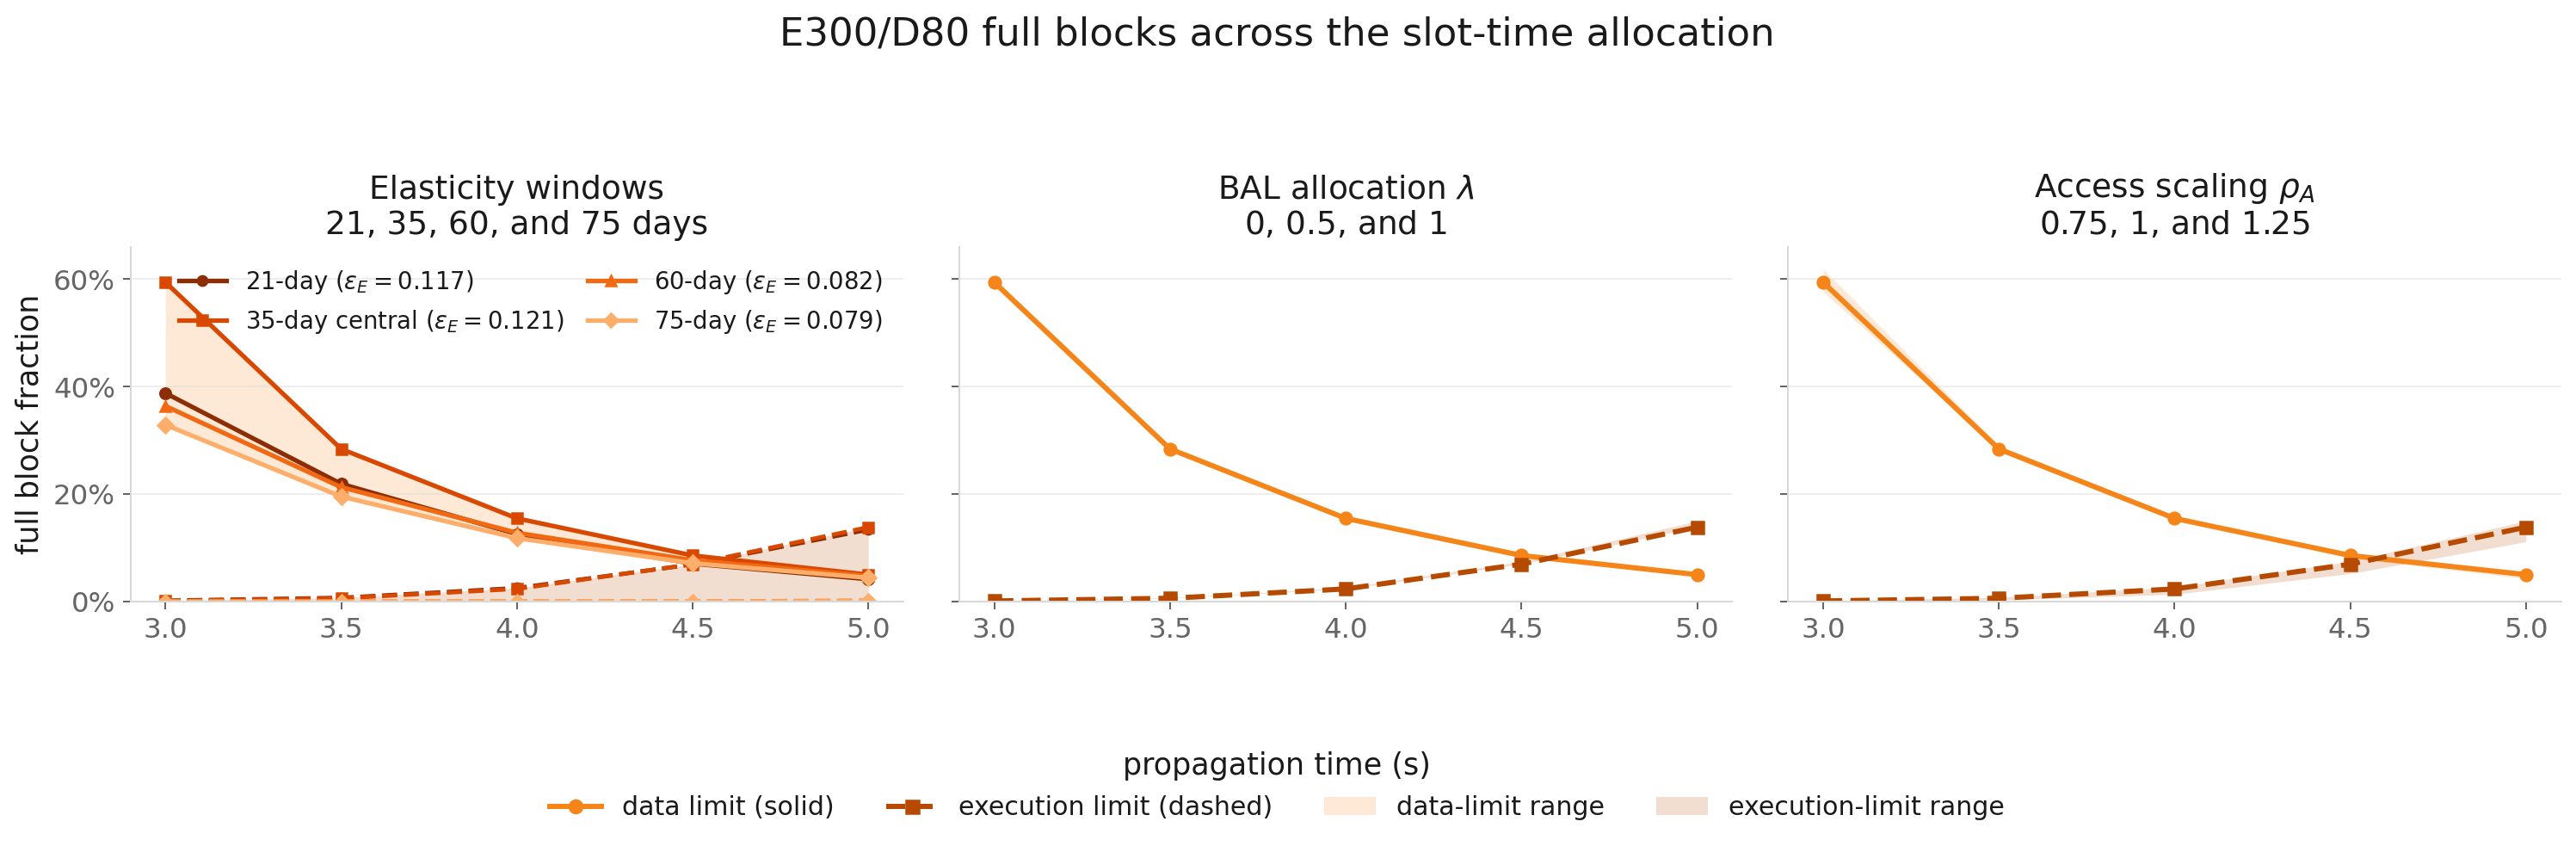

In [3]:
display(Image(
    filename=PLOTS_DIR / "slot_time_substitution_parameter_sensitivity.png"
))
display(Image(
    filename=PLOTS_DIR / "slot_time_substitution_parameter_sensitivity_full_blocks.png"
))

## Reproduce the two calibration regimes

The report separates demand-feasible specifications from the 60-/75-day demand-constrained estimates. This avoids presenting uncertainty about the demand curve as if it were uncertainty about physical slot-time capacity.

In [4]:
candidates = pd.read_csv(
    OUT_DIR / "slot_time_parameter_global_candidates.csv"
)
feasible = candidates[~candidates["window_days"].isin([60, 75])]
constrained = candidates[candidates["window_days"].isin([60, 75])]

summary = pd.DataFrame([
    {
        "calibration regime": "Demand-feasible: 21-/35-day and structural sensitivities",
        "maximum-throughput result": "4.5–5.0s, E300/D80–D100; 266–277M execution",
        "historically anchored result": "4.0s; 220–244M execution",
        "interpretation": "Propagation region is stable; exact targets vary",
    },
    {
        "calibration regime": "Demand-constrained: 60-/75-day",
        "maximum-throughput result": "Approximately 142–150M execution regardless of high target",
        "historically anchored result": "Approximately 142M where available",
        "interpretation": "Demand curve, not slot-time capacity, is binding",
    },
])
display(summary)
display(candidates)

assert len(candidates) == 8
assert set(feasible["maximum_propagation_time_s"]) == {4.5, 5.0}
assert feasible["maximum_execution_target"].eq(300e6).all()
assert feasible["maximum_data_target"].min() == 80e6
assert feasible["maximum_data_target"].max() == 100e6
assert 265 <= feasible["maximum_included_execution"].min() / 1e6 < 266
assert 276 < feasible["maximum_included_execution"].max() / 1e6 <= 277
assert set(feasible["historically_anchored_propagation_time_s"].dropna()) == {4.0}
assert 142 <= constrained["maximum_included_execution"].min() / 1e6 < 143
assert 150 <= constrained["maximum_included_execution"].max() / 1e6 < 151

,calibration regime,maximum-throughput result,historically anchored result,interpretation
0,Demand-feasible: 21-/35-day and structural sen...,"4.5–5.0s, E300/D80–D100; 266–277M execution",4.0s; 220–244M execution,Propagation region is stable; exact targets vary
1,Demand-constrained: 60-/75-day,Approximately 142–150M execution regardless of...,Approximately 142M where available,"Demand curve, not slot-time capacity, is binding"


,specification,window_days,lambda_bal,rho_A,is_central,maximum_propagation_time_s,maximum_execution_target,maximum_data_target,maximum_included_execution,historically_anchored_available,historically_anchored_propagation_time_s,historically_anchored_execution_target,historically_anchored_data_target,historically_anchored_included_execution
0,W21_L0_R1,21,0.0,1.00,False,4.5,300000000.0,80000000.0,2.686506e+08,True,4.0,250000000.0,52500000.0,2.424742e+08
1,W35_L0.5_R1,35,0.5,1.00,False,4.5,300000000.0,80000000.0,2.743107e+08,True,4.0,225000000.0,60000000.0,2.234611e+08
2,W35_L0_R0.75,35,0.0,0.75,False,4.5,300000000.0,80000000.0,2.766089e+08,True,4.0,250000000.0,52500000.0,2.436188e+08
3,W35_L0_R1,35,0.0,1.00,True,4.5,300000000.0,90000000.0,2.725975e+08,True,4.0,225000000.0,60000000.0,2.230036e+08
4,W35_L0_R1.25,35,0.0,1.25,False,5.0,300000000.0,100000000.0,2.656979e+08,True,4.0,225000000.0,60000000.0,2.202089e+08
5,W35_L1_R1,35,1.0,1.00,False,4.5,300000000.0,80000000.0,2.765013e+08,True,4.0,250000000.0,52500000.0,2.435863e+08
6,W60_L0_R1,60,0.0,1.00,False,5.0,300000000.0,80000000.0,1.500051e+08,True,5.0,150000000.0,80000000.0,1.422969e+08
7,W75_L0_R1,75,0.0,1.00,False,5.0,300000000.0,80000000.0,1.422243e+08,False,NaN,NaN,NaN,NaN


## Reproduced outputs

Together, the four notebooks regenerate every result table and figure cited by the dynamic report:

- the canonical multiscale empirical workload;
- the fixed-ratio target grid;
- the physical slot-time surfaces and candidate profiles;
- the 36-case fixed-design sensitivity;
- the eight complete selection-sensitivity surfaces and two-regime summary.